# Data Preprocessing

In [2]:
import pandas as pd

In [3]:
df = pd.read_excel("C:/Users/Admin/Desktop/Sharvari/Internship/FInal project/daily_trending_videos_xml.xlsx")
df.head()

,video_id,title,channel_title,country,views,likes,comments,published_at,trending_date
0,KDorKy-13ak,Kendrick Lamar's Apple Music Super Bowl Halfti...,NFL,US,33079510,1633864,98574,2025-02-10 08:52:55,2025-02-11 17:43:00
1,lI4dq7ffQy0,Kendrick Lamar Disses Drake During Halftime Sh...,E! News,US,1475936,12629,5126,2025-02-10 08:57:44,2025-02-11 17:43:00
2,Y5vgBxUuNlc,JAZZ at LAKERS | FULL GAME HIGHLIGHTS | Februa...,NBA,US,1841263,31666,2906,2025-02-11 11:42:20,2025-02-11 17:43:00
3,hUUszE29jS0,Marvel Studios’ Thunderbolts* | Big Game Trail...,Marvel Entertainment,US,9893431,204063,13864,2025-02-10 05:24:00,2025-02-11 17:43:00
4,jdX5xwV829s,The First Kiss in Brawl Stars!?,Brawl Stars,US,8354717,257108,17632,2025-02-10 14:28:00,2025-02-11 17:43:00


In [4]:
print(df.shape)

(674141, 9)


In [5]:
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")
print(df.columns)

Index(['video_id', 'title', 'channel_title', 'country', 'views', 'likes',
       'comments', 'published_at', 'trending_date'],
      dtype='object')


In [7]:
# Convert numeric columns
cols = ['views', 'likes', 'comments']
for col in cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')
# Convert date columns
df['published_at'] = pd.to_datetime(df['published_at'], errors='coerce')
df['trending_date'] = pd.to_datetime(df['trending_date'], errors='coerce')

In [8]:
# Check missing values
print(df.isnull().sum())

video_id          0
title             0
channel_title    14
country           0
views             0
likes             0
comments          0
published_at      0
trending_date    14
dtype: int64


In [9]:
#fill missing value
df['channel_title'] = df['channel_title'].fillna('Unknown')
#drop missing values
df = df.dropna(subset=['trending_date'])
print(df.isnull().sum())
#Convert trending_date properly
df['trending_date'] = pd.to_datetime(df['trending_date'], errors='coerce')
print("\n",df.shape)

video_id         0
title            0
channel_title    0
country          0
views            0
likes            0
comments         0
published_at     0
trending_date    0
dtype: int64

 (674127, 9)


In [10]:
# Remove Duplicates
df = df.sort_values(by='trending_date')
df = df.drop_duplicates(subset=['video_id', 'country', 'trending_date'], keep='last')

In [11]:
# Standardize Country Values
df['country'] = df['country'].str.upper().str.strip()

In [13]:
# Engagement Rate
df['engagement_rate'] = (df['likes'] + df['comments']) / df['views']
#print(df['engagement_rate'])

In [14]:
# Days to Trend
df['days_to_trend'] = (df['trending_date'] - df['published_at']).dt.days
#print(df['days_to_trend'])

In [15]:
# Popularity Buckets
df['popularity'] = pd.qcut(df['views'], q=4, labels=['Low', 'Medium', 'High', 'Viral'])
print(df['popularity'])

0          Viral
159       Medium
160         High
161         High
162          Low
           ...  
673544     Viral
673545     Viral
673546     Viral
673576     Viral
674140    Medium
Name: popularity, Length: 671536, dtype: category
Categories (4, object): ['Low' < 'Medium' < 'High' < 'Viral']


In [16]:
import re
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^\w\s]', '', text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

df['title_clean'] = df['title'].apply(clean_text)
df['channel_clean'] = df['channel_title'].apply(clean_text)

In [24]:
# Clean text
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^\w\s]', '', text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

df['title_clean'] = df['title'].apply(clean_text)

# Improved categorization
def categorize(title):
    title = str(title).lower()

    # 🎵 Music
    if any(word in title for word in ['song','music','album','lyrics','remix','dj']):
        return 'Music'
    
    # ⚽ Sports
    elif any(word in title for word in ['match','game','goal','highlights','cricket','football','ipl']):
        return 'Sports'
    
    # 📰 News
    elif any(word in title for word in ['news','breaking','update','report','live','election']):
        return 'News'
    
    # 🎮 Gaming
    elif any(word in title for word in ['gaming','gameplay','pubg','minecraft','fortnite','stream']):
        return 'Gaming'
    
    # 💻 Technology
    elif any(word in title for word in ['tech','review','unboxing','iphone','android','laptop','ai','gadget']):
        return 'Technology'
    
    # 📚 Education
    elif any(word in title for word in ['tutorial','learn','course','explained','how to']):
        return 'Education'
    
    # 😂 Comedy
    elif any(word in title for word in ['funny','comedy','prank','meme','roast']):
        return 'Comedy'
    
    # 🍔 Food
    elif any(word in title for word in ['food','recipe','cooking','kitchen']):
        return 'Food'
    
    # 👶 Kids
    elif any(word in title for word in ['kids','cartoon','nursery','rhymes']):
        return 'Kids'
    
    # 🧑 Lifestyle
    elif any(word in title for word in ['vlog','routine','travel','daily life']):
        return 'Lifestyle'
    
    # 🎬 Entertainment (broad fallback BEFORE Other)
    elif any(word in title for word in [
        'top','best','amazing','viral','challenge','reaction',
        'episode','show','video','performance','moments'
    ]):
        return 'Entertainment'
    
    # 🔥 FINAL fallback (small only)
    else:
        return 'Other'

# Apply
df['category'] = df['title_clean'].apply(categorize)

# Check distribution
print(df['category'].value_counts())

category
Other            477423
Entertainment     50755
Technology        48710
Sports            27341
Music             22067
Comedy            13100
News              11337
Gaming            10752
Education          4282
Lifestyle          2666
Food               2323
Kids                780
Name: count, dtype: int64


In [25]:
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
Index: 671536 entries, 0 to 674140
Data columns (total 15 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   video_id         671536 non-null  object        
 1   title            671536 non-null  object        
 2   channel_title    671536 non-null  object        
 3   country          671536 non-null  object        
 4   views            671536 non-null  int64         
 5   likes            671536 non-null  int64         
 6   comments         671536 non-null  int64         
 7   published_at     671536 non-null  datetime64[ns]
 8   trending_date    671536 non-null  datetime64[ns]
 9   engagement_rate  671435 non-null  float64       
 10  days_to_trend    671536 non-null  int64         
 11  popularity       671536 non-null  category      
 12  title_clean      671536 non-null  object        
 13  channel_clean    671536 non-null  object        
 14  category         671536 n

In [26]:
df.to_csv("C:/Users/Admin/Desktop/Sharvari/Internship/FInal project/cleaned_youtube_trending.csv", index=False)

# Sentiment Analysis

In [27]:
import pandas as pd
import numpy as np
import re

# NLP tools
from nltk.sentiment import SentimentIntensityAnalyzer
import nltk

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

In [28]:
# VADER (Valence Aware Dictionary for Sentiment Reasoning)
nltk.download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

In [29]:
df = pd.read_csv("C:/Users/Admin/Desktop/Sharvari/Internship/FInal project/cleaned_youtube_trending.csv")
df.head()

,video_id,title,channel_title,country,views,likes,comments,published_at,trending_date,engagement_rate,days_to_trend,popularity,title_clean,channel_clean,category
0,KDorKy-13ak,Kendrick Lamar's Apple Music Super Bowl Halfti...,NFL,US,33079510,1633864,98574,2025-02-10 08:52:55,2025-02-11 17:43:00,0.052372,1,Viral,kendrick lamars apple music super bowl halftim...,nfl,Music
1,rI99kfqg9p8,Teaser,VIVINOS,CA,939011,163233,13757,2025-02-10 14:30:54,2025-02-11 17:43:00,0.188486,1,Medium,teaser,vivinos,Other
2,hQfmvVZEMO8,Super Bowl 2025 LIVE: Chiefs vs. Eagles watch ...,Associated Press,CA,3968064,8832,2173,2025-02-10 09:11:22,2025-02-11 17:43:00,0.002773,1,High,super bowl 2025 live chiefs vs eagles watch pa...,associated press,News
3,O5GU7vvvRgA,As it aired: the Trump pregame interview on FOX,FOX54 News Huntsville,CA,2052575,41059,0,2025-02-10 03:02:30,2025-02-11 17:43:00,0.020004,1,High,as it aired the trump pregame interview on fox,fox54 news huntsville,Sports
4,ZXjRLWMxeho,Britton Moore Wins a Four-Chair Turn With Cold...,The Voice,CA,218244,4872,194,2025-02-11 08:30:36,2025-02-11 17:43:00,0.023213,0,Low,britton moore wins a fourchair turn with coldp...,the voice,Technology


In [30]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^\w\s]', '', text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

df['title_clean'] = df['title'].apply(clean_text)
df['channel_clean'] = df['channel_title'].apply(clean_text)

In [31]:
# Initialize Sentiment Analyzer
sia = SentimentIntensityAnalyzer()

In [32]:
df['title_clean'].isnull().sum()

np.int64(0)

In [33]:
df[df['title_clean'].apply(lambda x: isinstance(x, float))].head()

,video_id,title,channel_title,country,views,likes,comments,published_at,trending_date,engagement_rate,days_to_trend,popularity,title_clean,channel_clean,category


In [34]:
df['title_clean'] = df['title_clean'].astype(str)
df['title_clean'] = df['title_clean'].replace('nan', '')

In [35]:
# Get Sentiment Scores
def get_sentiment(text):
    if not isinstance(text, str) or text.strip() == "":
        return {'neg':0, 'neu':1, 'pos':0, 'compound':0}
    return sia.polarity_scores(text)

df['sentiment_scores'] = df['title_clean'].apply(get_sentiment)

In [39]:
# Extract Individual Scores
df['neg'] = df['sentiment_scores'].apply(lambda x: x['neg'])
df['neu'] = df['sentiment_scores'].apply(lambda x: x['neu'])
df['pos'] = df['sentiment_scores'].apply(lambda x: x['pos'])
df['compound'] = df['sentiment_scores'].apply(lambda x: x['compound'])

Key Metric: compound
    Range: -1 to +1
    Interpretation:
        0.05 → Positive
        < -0.05 → Negative
        Otherwise → Neutral

In [40]:
# Classify Sentiment
def classify_sentiment(score):
    if score > 0.05:
        return 'Positive'
    elif score < -0.05:
        return 'Negative'
    else:
        return 'Neutral'
df['sentiment'] = df['compound'].apply(classify_sentiment)

In [41]:
# Analyze Sentiment Distribution
df['sentiment'].value_counts()
df['sentiment'].value_counts(normalize=True) * 100

sentiment
Neutral     72.896017
Positive    17.440465
Negative     9.663518
Name: proportion, dtype: float64

In [42]:
df.groupby('sentiment')['views'].mean().sort_values(ascending=False)

sentiment
Positive    2.802552e+07
Negative    2.070210e+07
Neutral     8.393069e+06
Name: views, dtype: float64

In [43]:
df.groupby('sentiment')['views'].median()

sentiment
Negative     7022492.0
Neutral      1326756.0
Positive    12813819.0
Name: views, dtype: float64

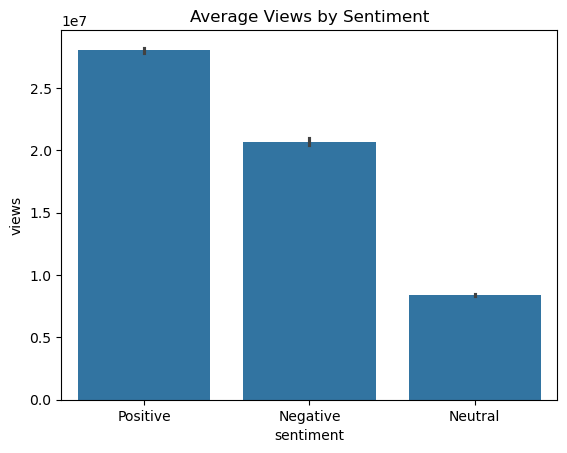

In [44]:
sns.barplot(x='sentiment', y='views', data=df, estimator=np.mean)
plt.title("Average Views by Sentiment")
plt.show()

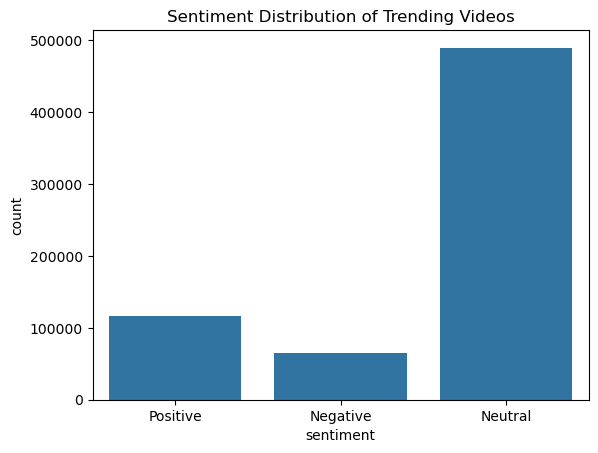

In [45]:
sns.countplot(x='sentiment', data=df)
plt.title("Sentiment Distribution of Trending Videos")
plt.show()

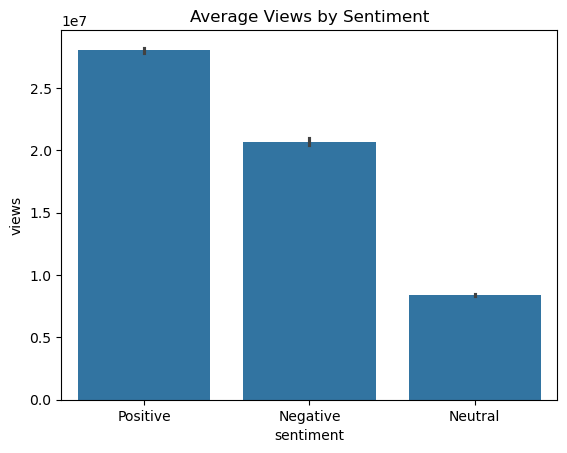

In [46]:
sns.barplot(x='sentiment', y='views', data=df, estimator=np.mean)
plt.title("Average Views by Sentiment")
plt.show()

In [50]:
df.to_csv("C:/Users/Admin/Desktop/Sharvari/Internship/FInal project/youtube_with_sentiment.csv", index=False)